In [ ]:
# Question # 1:Perform merging, grouping, concatenation and binning operations in Pandas.

# Steps:
# 1. Import pandas as pd and numpy as np.
# 2. Create Employees, Departments and Salaries DataFrames.
# 3. Perform merging:
#    - Inner join between employees and departments
#    - Left join between employees and departments
#    - Full outer join between employees and departments
# 4. Concatenate new employee records vertically.
# 5. Merge employees with salaries to create emp_salary.
# 6. Use groupby to calculate average salary by department.
# 7. Create salary bins using:
#    bins = [0, 60000, 80000, 100000]
#    labels = ['Low','Medium','High']
#    Use pd.cut() to create a new column salary_category.
# 8. Save final DataFrame to CSV file employee_summary.csv.

# Expected Skills:
# - pd.merge()
# - pd.concat()
# - groupby()
# - pd.cut()
# - df.to_csv()


In [2]:
import pandas as pd
import numpy as np

#Create DataFrames
employees = pd.DataFrame({
    'EmpID': [1, 2, 3, 4, 5],
    'Name': ['Alice','Bob','Charlie','Diana','Eve'],
    'DeptID': [101, 102, 101, 103, 102]
})

departments = pd.DataFrame({
    'DeptID': [101, 102, 103, 104],
    'DeptName': ['HR','Finance','IT','Marketing']
})

salaries = pd.DataFrame({
    'EmpID': [1,2,3,4,5],
    'Salary': [55000, 72000, 68000, 85000, 60000]
})

#Merging
inner_merge = pd.merge(employees, departments, on='DeptID', how='inner')
left_merge = pd.merge(employees, departments, on='DeptID', how='left')
outer_merge = pd.merge(employees, departments, on='DeptID', how='outer')

#Concatenate
new_employees = pd.DataFrame({
    'EmpID':[6,7],
    'Name':['Frank','Grace'],
    'DeptID':[103,104]
})
employees = pd.concat([employees, new_employees], ignore_index=True)

#Merge employees with salaries
emp_salary = pd.merge(employees, salaries, on='EmpID', how='left')

#calculate average salary using groupby
emp_salary = pd.merge(emp_salary, departments, on='DeptID', how='left')
avg_salary_by_dept = emp_salary.groupby('DeptName')['Salary'].mean().reset_index()

#Create bins of salary
bins = [0, 60000, 80000, 100000]
labels = ['Low','Medium','High']
emp_salary['salary_category'] = pd.cut(emp_salary['Salary'], bins=bins, labels=labels, right=False)

#Saving to csv
emp_salary.to_csv('employee_summary.csv', index=False)

print(emp_salary)
print("\nAverage Salary by Department:\n", avg_salary_by_dept)

   EmpID     Name  DeptID   Salary   DeptName salary_category
0      1    Alice     101  55000.0         HR             Low
1      2      Bob     102  72000.0    Finance          Medium
2      3  Charlie     101  68000.0         HR          Medium
3      4    Diana     103  85000.0         IT            High
4      5      Eve     102  60000.0    Finance          Medium
5      6    Frank     103      NaN         IT             NaN
6      7    Grace     104      NaN  Marketing             NaN

Average Salary by Department:
     DeptName   Salary
0    Finance  66000.0
1         HR  61500.0
2         IT  85000.0
3  Marketing      NaN


In [ ]:
# Question # 2:Create multiple visualizations using Pandas plotting and Seaborn.

# Steps:
# 1. Import pandas as pd, matplotlib.pyplot as plt and seaborn as sns.
# 2. Create the sales dataset with columns:
#    month, product_a, product_b, product_c, region.

# 3. Pandas Visualizations:
#    - Line plot of product sales over months
#    - Bar plot of product_a by month
#    - Pie chart of total sales by region

# 4. Seaborn Distribution Plots:
#    - distplot for product_a
#    - jointplot comparing product_a and product_b

# 5. Seaborn Categorical Plots:
#    - boxplot for product_a by region
#    - barplot showing average product sales by region

# 6. Matrix Plot:
#    - Create correlation matrix of product columns
#    - Visualize using sns.heatmap()

# 7. Add titles, labels and call plt.show() for each plot.


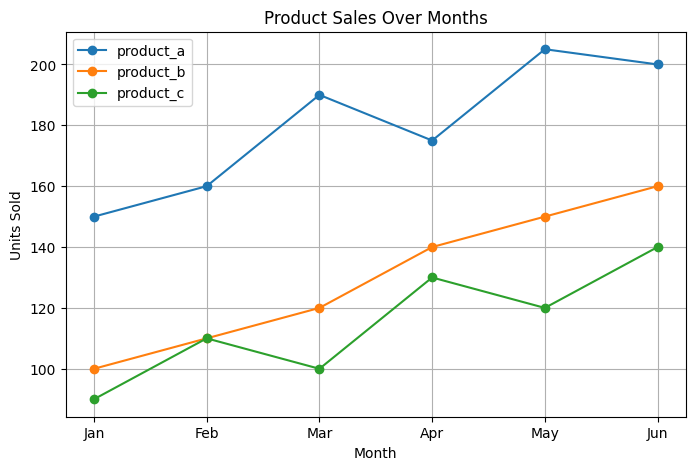

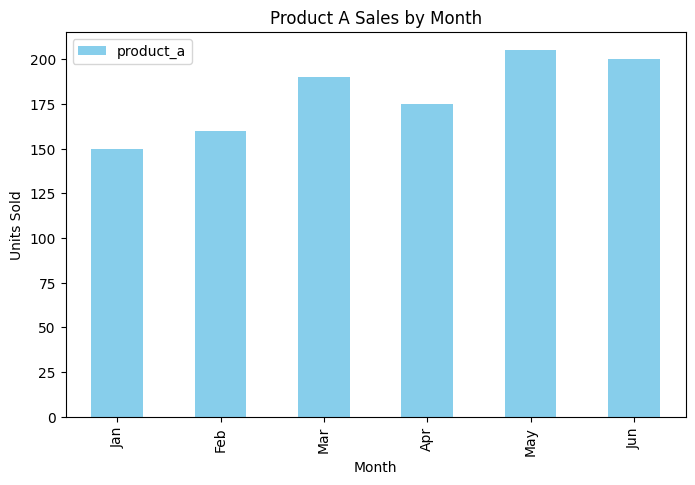

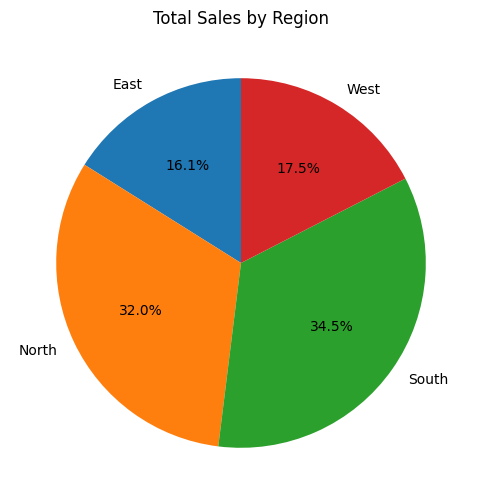

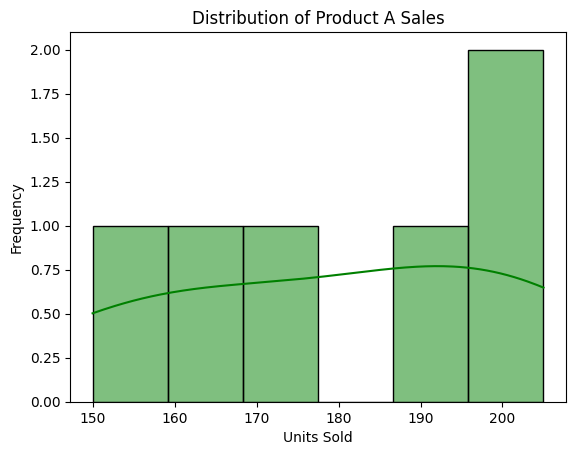

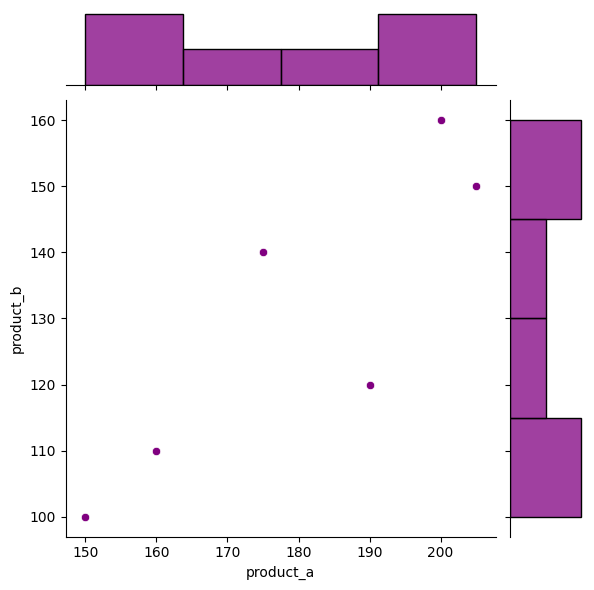

C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_2620\398894861.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='product_a', data=sales, palette='pastel')


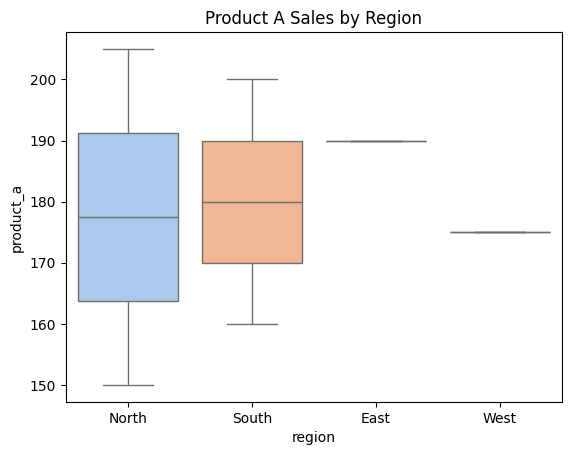

C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_2620\398894861.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='total_sales', data=sales, palette='viridis')


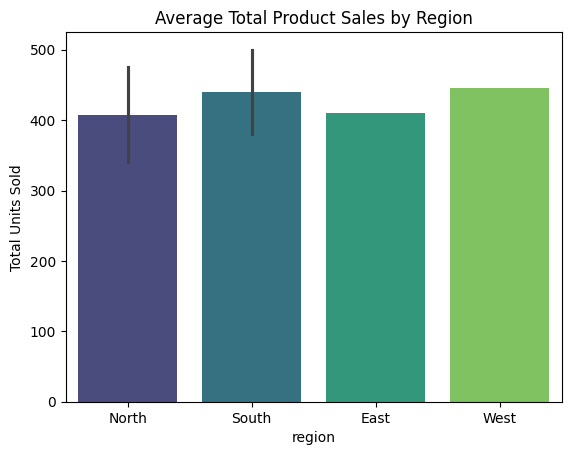

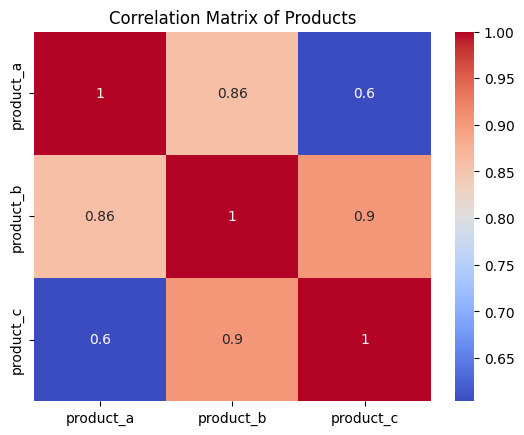

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Create dataset
sales = pd.DataFrame({
    'month': ['Jan','Feb','Mar','Apr','May','Jun'],
    'product_a': [150, 160, 190, 175, 205, 200],
    'product_b': [100, 110, 120, 140, 150, 160],
    'product_c': [90, 110, 100, 130, 120, 140],
    'region': ['North','South','East','West','North','South']
})

#Line plot of product sales over months
sales.set_index('month')[['product_a','product_b','product_c']].plot(marker='o', figsize=(8,5))
plt.title('Product Sales Over Months')
plt.ylabel('Units Sold')
plt.xlabel('Month')
plt.grid(True)
plt.show()

#Bar plot of product_a by month
sales.plot(x='month', y='product_a', kind='bar', color='skyblue', figsize=(8,5))
plt.title('Product A Sales by Month')
plt.ylabel('Units Sold')
plt.xlabel('Month')
plt.show()

#Pie chart of total sales by region
region_sales = sales.groupby('region')[['product_a','product_b','product_c']].sum().sum(axis=1)
region_sales.plot.pie(autopct='%1.1f%%', figsize=(6,6), startangle=90)
plt.title('Total Sales by Region')
plt.ylabel('')
plt.show()

#Seaborn Distribution Plots
sns.histplot(sales['product_a'], kde=True, color='green', bins=6)
plt.title('Distribution of Product A Sales')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

#Jointplot comparing product_a and product_b
sns.jointplot(x='product_a', y='product_b', data=sales, kind='scatter', color='purple')
plt.show()

#Boxplot for product_a by region
sns.boxplot(x='region', y='product_a', data=sales, palette='pastel')
plt.title('Product A Sales by Region')
plt.show()

#Barplot showing average product sales by region
sales['total_sales'] = sales[['product_a','product_b','product_c']].sum(axis=1)
sns.barplot(x='region', y='total_sales', data=sales, palette='viridis')
plt.title('Average Total Product Sales by Region')
plt.ylabel('Total Units Sold')
plt.show()

# Correlation matrix of product columns
corr_matrix = sales[['product_a','product_b','product_c']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Products')
plt.show()

In [ ]:
# Question # 3:Implement linear regression using gradient descent.

# Dataset:
# Hours studied vs exam score

# Steps:
# 1. Import numpy and matplotlib.
# 2. Create dataset:
#    X = hours studied
#    y = exam scores

# 3. Initialize parameters:
#    m = 0
#    b = 0
#    learning rate = 0.01
#    epochs = 1000

# 4. Implement prediction:
#    y_pred = m*X + b

# 5. Implement cost function:
#    Mean Squared Error

# 6. Compute gradients:
#    m_gradient
#    b_gradient

# 7. Update parameters using gradient descent.

# 8. Print cost every 100 epochs.

# 9. After training:
#    Print final slope and intercept.

# 10. Make predictions for:
#     4.5 hours
#     7.5 hours

# 11. Plot:
#     Scatter plot of data
#     Regression line


Epoch 0, Cost: 4032.5000
Epoch 100, Cost: 84.7902
Epoch 200, Cost: 37.7160
Epoch 300, Cost: 17.4276
Epoch 400, Cost: 8.6836
Epoch 500, Cost: 4.9150
Epoch 600, Cost: 3.2908
Epoch 700, Cost: 2.5908
Epoch 800, Cost: 2.2891
Epoch 900, Cost: 2.1591

Final Slope (m): 5.5488
Final Intercept (b): 30.8883
Predicted score for 4.5 hours: 55.86
Predicted score for 7.5 hours: 72.50


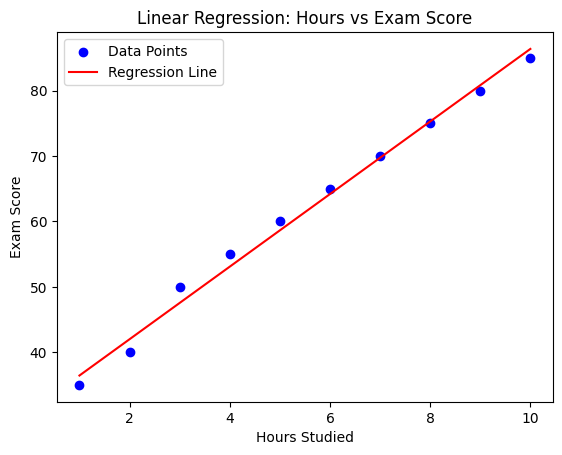

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # hours studied
y = np.array([35, 40, 50, 55, 60, 65, 70, 75, 80, 85])  # exam scores

#Initialize parameters
m = 0  
b = 0  
learning_rate = 0.01
epochs = 1000
n = float(len(X))

#Gradient Descent
for i in range(epochs):
    y_pred = m * X + b
    #Cost Function (MSE)
    cost = (1/n) * np.sum((y - y_pred)**2)
  
    m_gradient = -(2/n) * np.sum(X * (y - y_pred))
    b_gradient = -(2/n) * np.sum(y - y_pred)
    
    #Update Parameters
    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient
    
    #Print cost every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i}, Cost: {cost:.4f}")

#Final parameters
print(f"\nFinal Slope (m): {m:.4f}")
print(f"Final Intercept (b): {b:.4f}")

#Predictions
hours = [4.5, 7.5]
predictions = [m*h + b for h in hours]
for h, p in zip(hours, predictions):
    print(f"Predicted score for {h} hours: {p:.2f}")

#Plotting
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, m*X + b, color='red', label='Regression Line')
plt.title('Linear Regression: Hours vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()